# Assignment 3: Data Identification and ML Workflow

**Course:** AI for Engineering

**Student:** Jacob Muema Makile

**Registration Number:** ENM 231 0086/2020

**Date:** October 2026

## Project Problem Restatement

**Problem:** Container glass manufacturing in Kenya faces a critical operational challenge: inconsistent and contaminated recycled glass (cullet) feedstock. Contaminants like Ceramic-Stone-Porcelain (CSP) and Pyrex disrupt melting kinetics, create weak points in finished bottles, and damage furnace refractory linings. Manual sorting cannot keep pace with production speeds (>5 tons/hour), and there is no real-time system to classify incoming cullet or predict its composition.

**Intended AI/ML Outcome:** Develop a machine learning system that can:
1. Classify incoming cullet particles as acceptable (soda-lime container glass) or contaminated (CSP, Pyrex, lead crystal)
2. Classify glass by color (clear, green, amber, mixed) for proper batch formulation
3. Achieve >98% classification accuracy at production line speeds

This will enable real-time sorting, reduce furnace feed variability, and support Kenya's EPR Regulations, 2024.

## Data Needed for This Project

To train an ML model for cullet classification, the following data is required:

### 1. Image Data (Primary Input)
- Labeled images of glass particles by type: soda-lime clear, soda-lime green, soda-lime amber, CSP (ceramic/stone/porcelain), Pyrex (borosilicate)
- Image characteristics: High-resolution (ideally >256×256 pixels), various lighting conditions, diverse backgrounds
- Quantity: Minimum 5,000 images per class for robust training

### 2. Spectral Data (Optional Enhancement)
- Near-infrared (NIR) spectra of different glass types
- X-ray fluorescence (XRF) spectra for elemental composition

### 3. Process Data (For Optimization)
- Furnace temperature profiles
- Oxygen-to-fuel ratios
- Batch composition records
- Energy consumption data

### 4. Quality Control Data
- Product defect rates
- Refractory lining wear data

## Dataset Selection

Since direct data from Kenyan glass manufacturing facilities is not publicly available, I will use a relevant dataset from Kaggle.

**Dataset:** Garbage Dataset (GD): A Multi-Class Image Benchmark for Automated Waste Segregation

**Source:** Kaggle — https://www.kaggle.com/datasets/sumn2u/garbage-classification-v2/

**Why this dataset:**
- Contains glass images as a distinct category
- Contains metal, paper, cardboard, plastic images useful for contaminant detection
- 13,348 total images across 10 classes
- Well-documented with academic paper reference

**Limitation:** This dataset does not distinguish between CSP, Pyrex, and soda-lime glass specifically. However, it provides a foundation for waste classification that can be extended.

In [ ]:
# ============================================
# CELL 5: INSTALL KAGGLE AND UPLOAD API KEY
# ============================================

# Install Kaggle API
!pip install kaggle -q

# Upload kaggle.json file
from google.colab import files
print("Please upload your kaggle.json file:")
uploaded = files.upload()

# Configure Kaggle
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

print("Kaggle API configured successfully!")

In [ ]:
# ============================================
# CELL 6: DOWNLOAD AND EXTRACT DATASET
# ============================================

# Download the Garbage Dataset
!kaggle datasets download -d sumn2u/garbage-classification-v2

# Extract the dataset
!unzip -q garbage-classification-v2.zip -d garbage_dataset

# Verify download
import os
print("\nDataset contents:")
for root, dirs, files in os.walk('garbage_dataset'):
    level = root.replace('garbage_dataset', '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 2:
        for file in files[:3]:
            print(f'{indent}  {file}')

Total images found: 0


IndexError: Cannot choose from an empty sequence

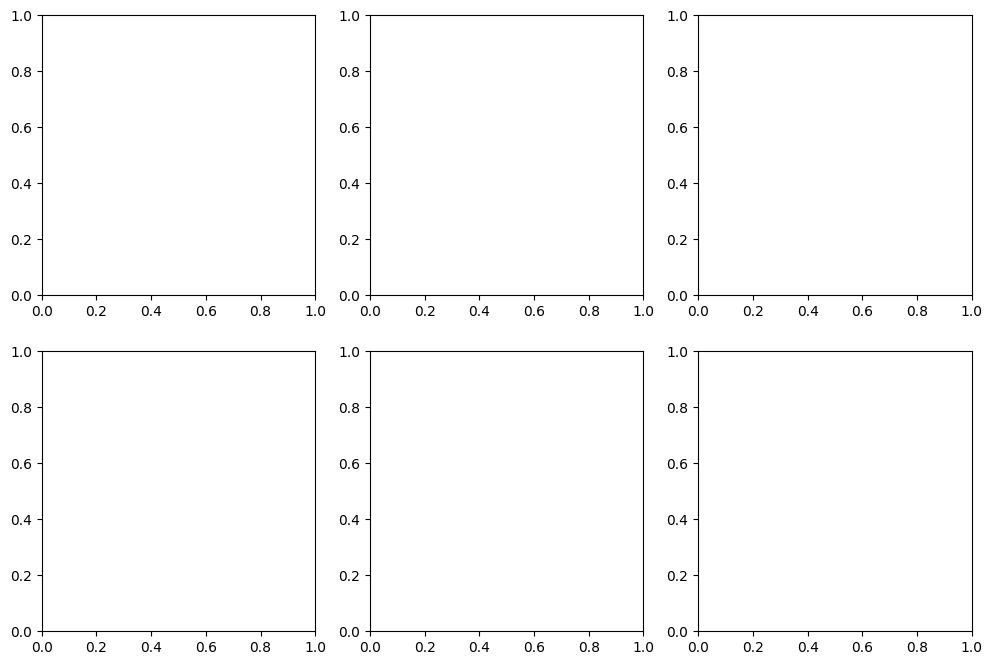

In [4]:
# ============================================
# CELL 7: DISPLAY SAMPLE IMAGES
# ============================================

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
import random

# Find image directory
dataset_path = 'garbage_dataset'
image_dirs = []

for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.endswith(('.jpg', '.jpeg', '.png')):
            image_dirs.append(os.path.join(root, file))

print(f"Total images found: {len(image_dirs)}")

# Display 6 random images
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for i in range(6):
    img_path = random.choice(image_dirs)
    img = mpimg.imread(img_path)
    axes[i].imshow(img)
    class_name = img_path.split('/')[-2]
    axes[i].set_title(f"Class: {class_name}")
    axes[i].axis('off')

plt.tight_layout()
plt.suptitle("Sample Images from Garbage Dataset", fontsize=14, y=1.02)
plt.show()

--- Class Distribution ---


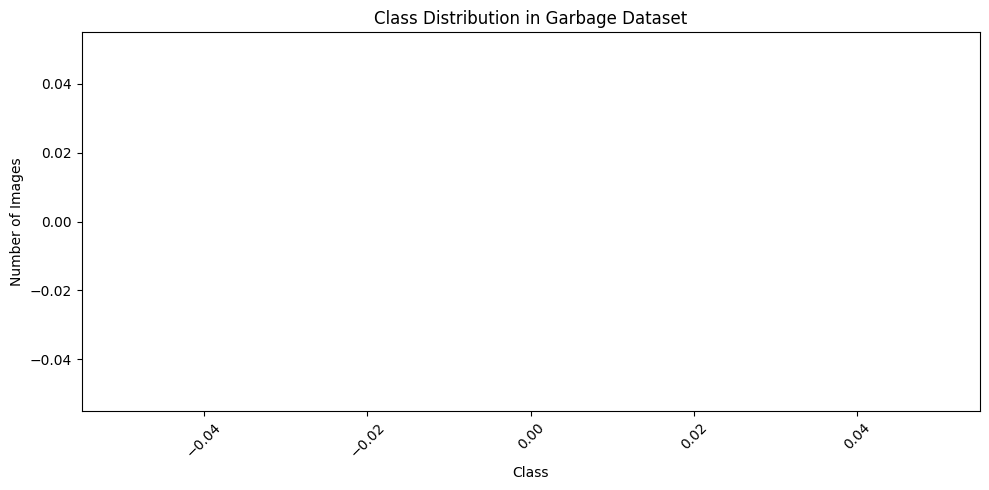

In [3]:
# ============================================
# CELL 8: SHOW CLASS DISTRIBUTION
# ============================================

# Count images per class
class_counts = {}
for img_path in image_dirs:
    class_name = img_path.split('/')[-2]
    class_counts[class_name] = class_counts.get(class_name, 0) + 1

# Display class distribution
print("--- Class Distribution ---")
for class_name, count in sorted(class_counts.items()):
    print(f"{class_name}: {count} images")

# Plot bar chart
plt.figure(figsize=(10, 5))
plt.bar(class_counts.keys(), class_counts.values(), color='steelblue')
plt.title("Class Distribution in Garbage Dataset")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [2]:
## Potential Inputs (Features) and Output (Target)

### Input Features (X):
| Feature | Description | Data Type |
|---------|-------------|-----------|
| Image pixels | RGB values for each pixel | Numerical (0-255) |
| Image size | Resized to 224×224 pixels | Numerical |
| Color distribution | Histogram of colors | Numerical |
| Texture features | Edge density, smoothness | Numerical |

### Output Target (y):
| Target | Description | Type |
|--------|-------------|------|
| Class label | Glass, Metal, Paper, Cardboard, Plastic, Trash | Categorical |

### ML Problem Type:
**Multi-class Image Classification** — supervised learning where the model assigns each image to one of several predefined categories.

SyntaxError: invalid character '×' (U+00D7) (3827907434.py, line 7)

## Proposed ML Workflow


## Summary

This notebook has:
1. Restated the project problem and intended AI/ML outcome
2. Identified the data needed for cullet classification
3. Selected the Garbage Dataset from Kaggle
4. Imported and displayed sample images
5. Identified features (image pixels) and target (class label)
6. Presented the proposed ML workflow

**Next Steps:**
- Preprocess images (resize, normalize, augment)
- Train CNN model using transfer learning
- Evaluate model performance
- Deploy for real-time cullet classification